IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np

LOAD DATASET

In [2]:
df = pd.read_csv(r'd:\internship\PS2_Dataset.csv')

printing FIRST 5 ROWS

In [3]:
print("First 5 rows:")
df.head()

First 5 rows:


,Logical quotient rating,hackathons,coding skills rating,public speaking points,self-learning capability?,Extra-courses did,certifications,workshops,reading and writing skills,memory capability score,Interested subjects,interested career area,Type of company want to settle in?,Taken inputs from seniors or elders,Interested Type of Books,Management or Technical,hard/smart worker,worked in teams ever?,Introvert,Suggested Job Role
0,5,0,6,2,yes,no,information security,testing,poor,poor,programming,testing,BPA,no,Series,Management,smart worker,yes,no,Applications Developer
1,7,6,4,3,no,yes,shell programming,testing,excellent,medium,Management,system developer,Cloud Services,yes,Autobiographies,Technical,hard worker,no,yes,Applications Developer
2,2,3,9,1,no,yes,information security,testing,excellent,poor,data engineering,Business process analyst,product development,yes,Travel,Technical,smart worker,no,no,Applications Developer
3,2,6,3,5,no,yes,r programming,database security,excellent,poor,networks,testing,Testing and Maintainance Services,yes,Guide,Management,smart worker,yes,yes,Applications Developer
4,2,0,3,4,yes,no,distro making,game development,excellent,medium,Software Engineering,system developer,BPA,no,Health,Technical,hard worker,yes,no,Applications Developer


Shape of the data

In [4]:
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

Dataset has 6901 rows and 20 columns


column info

In [5]:
print("\nColumn info:")
df.info()


Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6901 entries, 0 to 6900
Data columns (total 20 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Logical quotient rating              6901 non-null   int64 
 1   hackathons                           6901 non-null   int64 
 2   coding skills rating                 6901 non-null   int64 
 3   public speaking points               6901 non-null   int64 
 4   self-learning capability?            6901 non-null   object
 5   Extra-courses did                    6901 non-null   object
 6   certifications                       6901 non-null   object
 7   workshops                            6901 non-null   object
 8   reading and writing skills           6901 non-null   object
 9   memory capability score              6901 non-null   object
 10  Interested subjects                  6901 non-null   object
 11  interested career area       

Summary statistics for numerical columns

In [6]:
print("\nNumerical summary:")
df.describe()


Numerical summary:


,Logical quotient rating,hackathons,coding skills rating,public speaking points
count,6901.000000,6901.000000,6901.000000,6901.000000
mean,4.991016,2.999710,5.010723,4.988263
std,2.577704,2.010191,2.568347,2.599500
min,1.000000,0.000000,1.000000,1.000000
25%,3.000000,1.000000,3.000000,3.000000
50%,5.000000,3.000000,5.000000,5.000000
75%,7.000000,5.000000,7.000000,7.000000
max,9.000000,6.000000,9.000000,9.000000


In [7]:
print("\nMissing values per column:")
df.isnull().sum()


Missing values per column:


Logical quotient rating                0
hackathons                             0
coding skills rating                   0
public speaking points                 0
self-learning capability?              0
Extra-courses did                      0
certifications                         0
workshops                              0
reading and writing skills             0
memory capability score                0
Interested subjects                    0
interested career area                 0
Type of company want to settle in?     0
Taken inputs from seniors or elders    0
Interested Type of Books               0
Management or Technical                0
hard/smart worker                      0
worked in teams ever?                  0
Introvert                              0
Suggested Job Role                     0
dtype: int64

In [8]:
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


*CHECKING BALANCE IN DATASET.*

this gives the number if roles and their respective counts amoung all (6900) entries.

In [9]:
print("Job Role Distribution:")
print(df['Suggested Job Role'].value_counts())
print(f"\nTotal unique roles: {df['Suggested Job Role'].nunique()}")

Job Role Distribution:
Suggested Job Role
Network Security Engineer                    630
Software Engineer                            590
UX Designer                                  589
Software Developer                           587
Database Developer                           581
Software Quality Assurance (QA) / Testing    571
Web Developer                                570
CRM Technical Developer                      567
Technical Support                            565
Systems Security Administrator               562
Applications Developer                       551
Mobile Applications Developer                538
Name: count, dtype: int64

Total unique roles: 12


In [12]:
binary_cols = ['self-learning capability?', 'Extra-courses did',
               'worked in teams ever?', 'Introvert',
               'Taken inputs from seniors or elders']
for col in binary_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


self-learning capability?:
self-learning capability?
yes    3496
no     3405
Name: count, dtype: int64

Extra-courses did:
Extra-courses did
no     3529
yes    3372
Name: count, dtype: int64

worked in teams ever?:
worked in teams ever?
no     3470
yes    3431
Name: count, dtype: int64

Introvert:
Introvert
yes    3544
no     3357
Name: count, dtype: int64

Taken inputs from seniors or elders:
Taken inputs from seniors or elders
yes    3501
no     3400
Name: count, dtype: int64


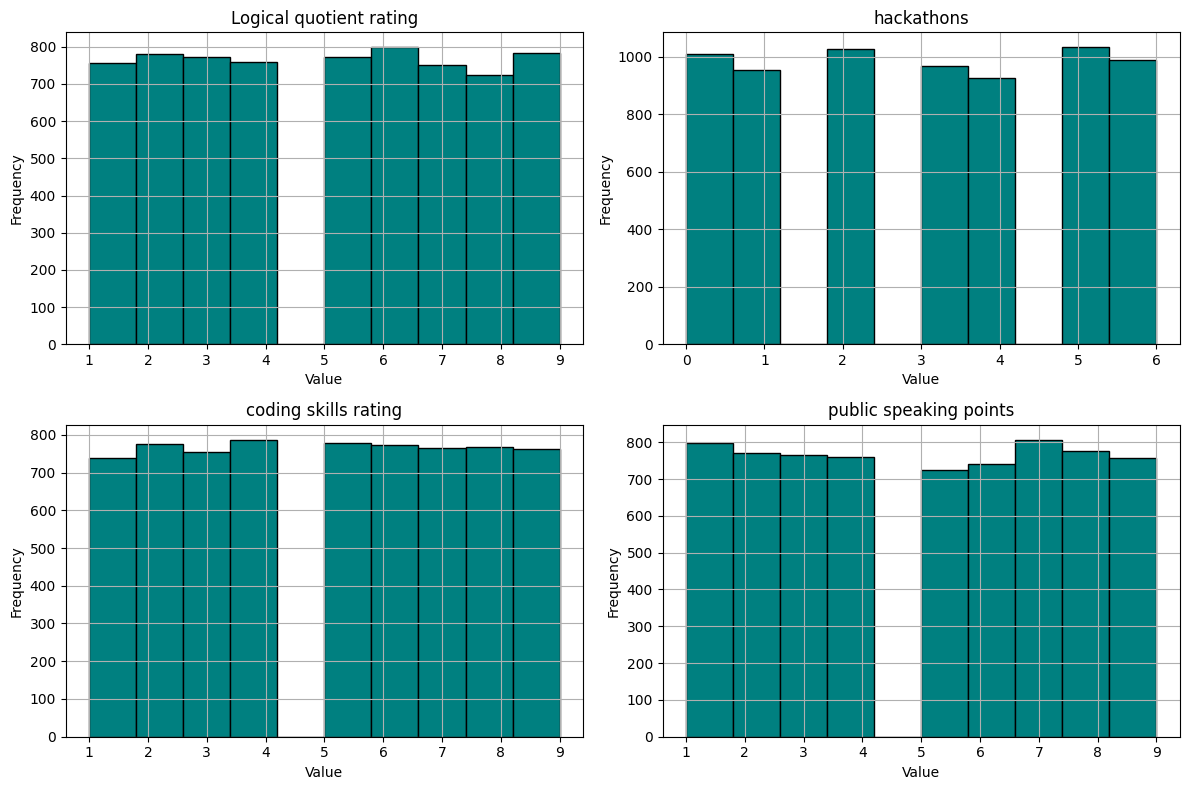

In [13]:
numerical_cols = ['Logical quotient rating', 'hackathons',
                  'coding skills rating', 'public speaking points']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(numerical_cols):
    ax = axes[i // 2, i % 2]
    df[col].hist(bins=10, ax=ax, color='teal', edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig(r'd:\internship\reports\numerical_distributions.png')
plt.show()


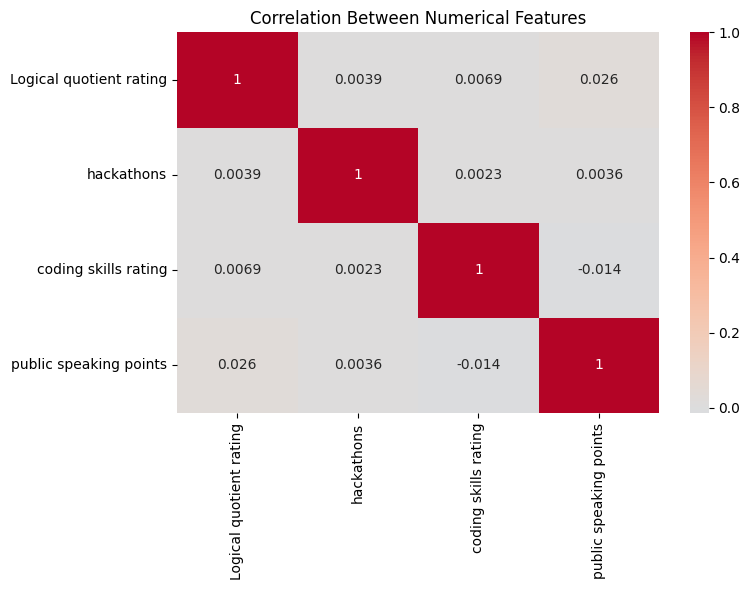

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Numerical Features')
plt.tight_layout()
plt.savefig(r'd:\internship\reports\correlation_heatmap.png')
plt.show()

In [16]:
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)
print(f"Total samples: {len(df)}")
print(f"Total features: {df.shape[1] - 1}")
print(f"Target classes: {df['Suggested Job Role'].nunique()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

EDA SUMMARY
Total samples: 6901
Total features: 19
Target classes: 12
Missing values: 0
Duplicate rows: 0


Converting binary columns to 1 and  0.

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
binary_cols = ['self-learning capability?', 'Extra-courses did',
               'worked in teams ever?', 'Introvert',
               'Taken inputs from seniors or elders']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})
    print(f"Encoded {col}: {df[col].unique()}")


Encoded self-learning capability?: [1 0]
Encoded Extra-courses did: [0 1]
Encoded worked in teams ever?: [1 0]
Encoded Introvert: [0 1]
Encoded Taken inputs from seniors or elders: [0 1]


In [19]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

In [20]:
ordinal_map_rw = {'poor': 0, 'medium': 1, 'excellent': 2}
df['reading and writing skills'] = df['reading and writing skills'].map(ordinal_map_rw)

ordinal_map_mem = {'poor': 0, 'medium': 1, 'excellent': 2}
df['memory capability score'] = df['memory capability score'].map(ordinal_map_mem)

df['Management or Technical'] = df['Management or Technical'].map({
    'Management': 0, 'Technical': 1
})

df['hard/smart worker'] = df['hard/smart worker'].map({
    'hard worker': 0, 'smart worker': 1
})
print("\nAfter encoding binary/ordinal columns:")
print(df.dtypes)


After encoding binary/ordinal columns:
Logical quotient rating                 int64
hackathons                              int64
coding skills rating                    int64
public speaking points                  int64
self-learning capability?               int64
Extra-courses did                       int64
certifications                         object
workshops                              object
reading and writing skills              int64
memory capability score                 int64
Interested subjects                    object
interested career area                 object
Type of company want to settle in?     object
Taken inputs from seniors or elders     int64
Interested Type of Books               object
Management or Technical                 int64
hard/smart worker                       int64
worked in teams ever?                   int64
Introvert                               int64
Suggested Job Role                     object
dtype: object


In [22]:
# Step 1: Identify remaining text columns (excluding target)
remaining_cat_cols = df.select_dtypes(include='object').columns.tolist()
remaining_cat_cols.remove('Suggested Job Role')  # keep target separate
print(f"Columns still needing encoding: {remaining_cat_cols}")

# Step 2: Use Label Encoding for each
# (Label Encoding is simpler for tree-based models like Random Forest)
label_encoders = {}
for col in remaining_cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"Encoded '{col}': {len(le.classes_)} unique values → {df[col].unique()[:5]}...")

# Step 3: Save the encoders for later use in the app
import joblib
joblib.dump(label_encoders, r'd:\internship\models\label_encoders.pkl')
print("\nLabel encoders saved!")

# Step 4: Verify — all columns should now be numeric (except target)
print("\nFinal data types:")
print(df.dtypes)

# Step 5: Save the preprocessed data
df.to_csv(r'd:\internship\PS2_Dataset_preprocessed.csv', index=False)
print(f"\nPreprocessed dataset saved! Shape: {df.shape}")


Columns still needing encoding: ['certifications', 'workshops', 'Interested subjects', 'interested career area ', 'Type of company want to settle in?', 'Interested Type of Books']
Encoded 'certifications': 9 unique values → [4 8 7 1 5]...
Encoded 'workshops': 8 unique values → [6 2 3 1 5]...
Encoded 'Interested subjects': 10 unique values → [9 2 5 7 3]...
Encoded 'interested career area ': 6 unique values → [5 4 0 3 2]...
Encoded 'Type of company want to settle in?': 10 unique values → [0 1 9 7 4]...
Encoded 'Interested Type of Books': 31 unique values → [28  3 29 13 14]...

Label encoders saved!

Final data types:
Logical quotient rating                  int64
hackathons                               int64
coding skills rating                     int64
public speaking points                   int64
self-learning capability?                int64
Extra-courses did                        int64
certifications                           int64
workshops                                int64
r

SPLITING

In [23]:
from sklearn.model_selection import train_test_split

# Step 1: Load preprocessed data (or continue from above)
df = pd.read_csv(r'd:\internship\PS2_Dataset_preprocessed.csv')

# Step 2: Separate features (X) and target (y)
X = df.drop('Suggested Job Role', axis=1)  # Everything except the target
y = df['Suggested Job Role']               # Only the target

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

# Step 3: Encode the target variable
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)
print(f"\nTarget classes: {list(target_encoder.classes_)}")
print(f"Encoded as: {list(range(len(target_encoder.classes_)))}")

# Save target encoder
joblib.dump(target_encoder, r'd:\internship\models\target_encoder.pkl')

# Step 4: Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

# Step 5: Save the splits
import numpy as np
np.save(r'd:\internship\models\X_train.npy', X_train)
np.save(r'd:\internship\models\X_test.npy', X_test)
np.save(r'd:\internship\models\y_train.npy', y_train)
np.save(r'd:\internship\models\y_test.npy', y_test)

# Also save feature names for the app
joblib.dump(list(X.columns), r'd:\internship\models\feature_names.pkl')
print("\nAll data saved!")


Features (X) shape: (6901, 19)
Target (y) shape: (6901,)

Feature columns: ['Logical quotient rating', 'hackathons', 'coding skills rating', 'public speaking points', 'self-learning capability?', 'Extra-courses did', 'certifications', 'workshops', 'reading and writing skills', 'memory capability score', 'Interested subjects', 'interested career area ', 'Type of company want to settle in?', 'Taken inputs from seniors or elders', 'Interested Type of Books', 'Management or Technical', 'hard/smart worker', 'worked in teams ever?', 'Introvert']

Target classes: ['Applications Developer', 'CRM Technical Developer', 'Database Developer', 'Mobile Applications Developer', 'Network Security Engineer', 'Software Developer', 'Software Engineer', 'Software Quality Assurance (QA) / Testing', 'Systems Security Administrator', 'Technical Support', 'UX Designer', 'Web Developer']
Encoded as: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

Training set: 5520 samples
Testing set:  1381 samples

All data saved!


In [24]:
import pandas as pd
import numpy as np
import joblib
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load data
X_train = np.load(r'd:\internship\models\X_train.npy', allow_pickle=True)
X_test = np.load(r'd:\internship\models\X_test.npy', allow_pickle=True)
y_train = np.load(r'd:\internship\models\y_train.npy', allow_pickle=True)
y_test = np.load(r'd:\internship\models\y_test.npy', allow_pickle=True)
target_encoder = joblib.load(r'd:\internship\models\target_encoder.pkl')

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Evaluate
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_dt,
                            target_names=target_encoder.classes_))


Decision Tree Accuracy: 0.0833 (8.33%)

Classification Report:
                                           precision    recall  f1-score   support

                   Applications Developer       0.05      0.05      0.05       110
                  CRM Technical Developer       0.08      0.08      0.08       114
                       Database Developer       0.12      0.09      0.11       116
            Mobile Applications Developer       0.07      0.07      0.07       108
                Network Security Engineer       0.08      0.08      0.08       126
                       Software Developer       0.11      0.10      0.10       118
                        Software Engineer       0.07      0.08      0.07       118
Software Quality Assurance (QA) / Testing       0.05      0.05      0.05       114
           Systems Security Administrator       0.11      0.12      0.11       112
                        Technical Support       0.04      0.04      0.04       113
                       

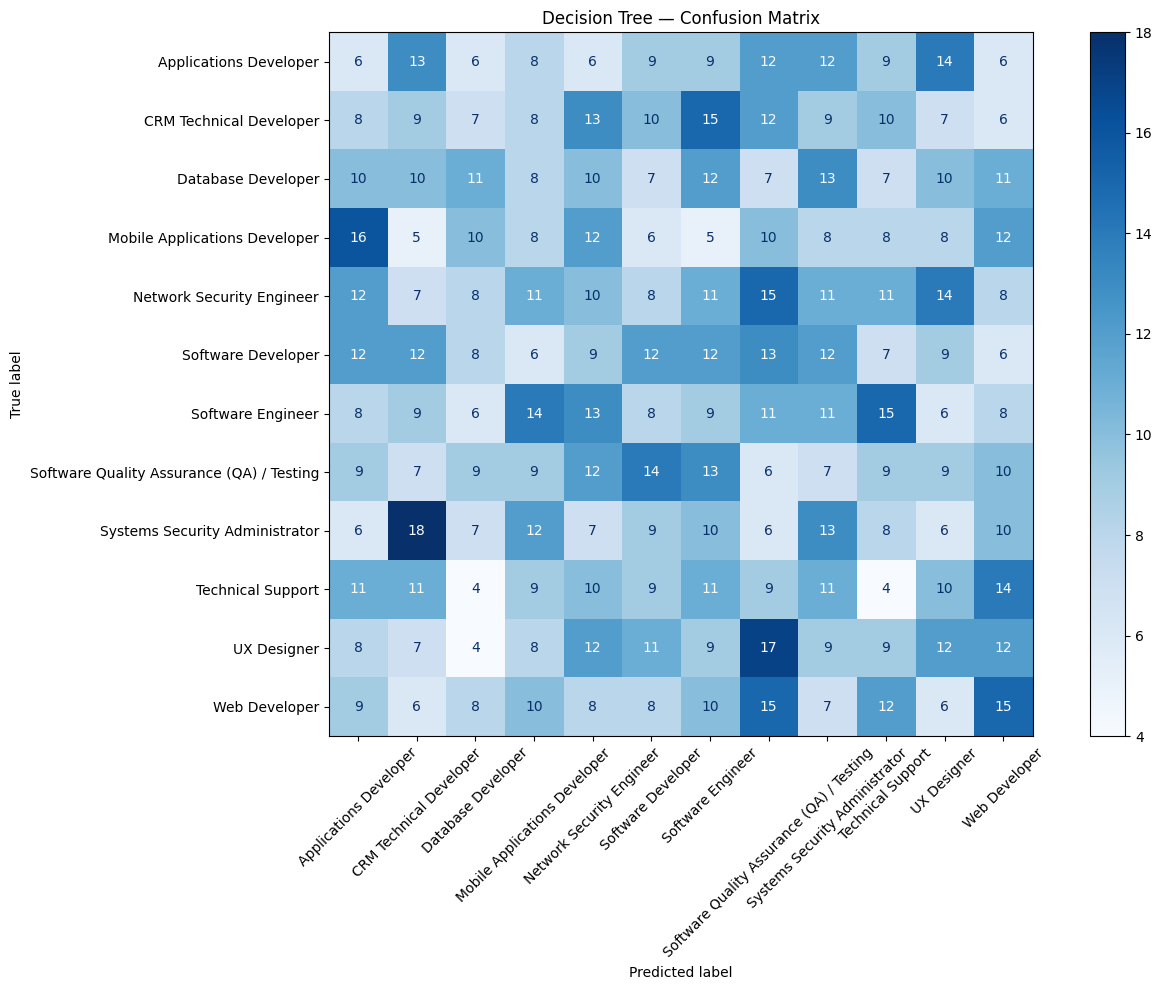

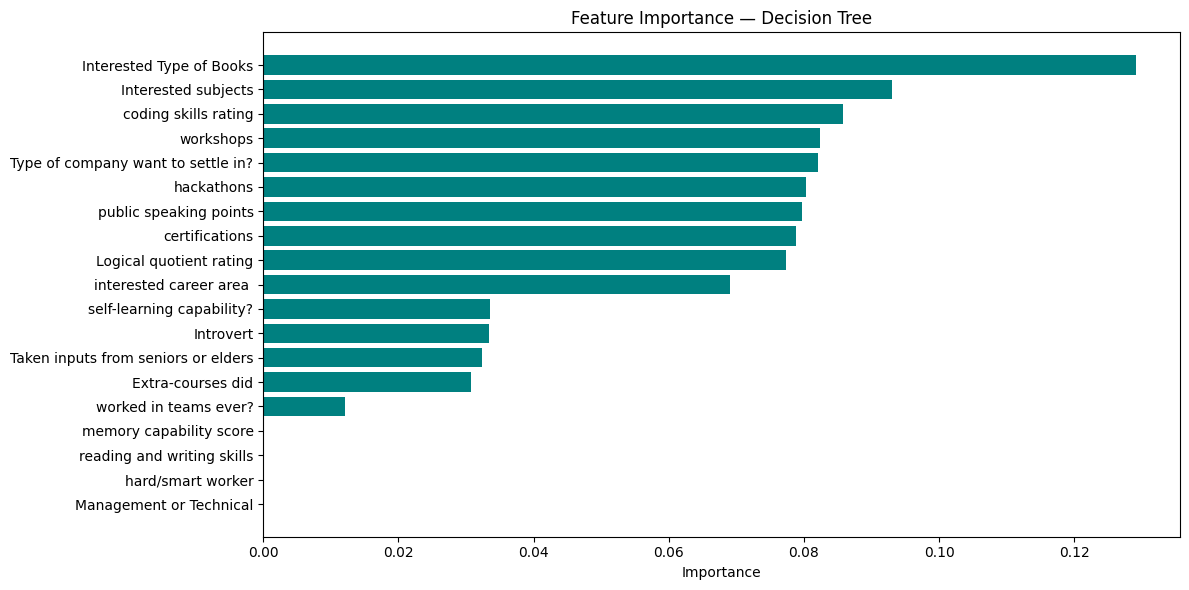


Top 5 most important features:
                               Feature  Importance
14            Interested Type of Books    0.129182
10                 Interested subjects    0.092966
2                 coding skills rating    0.085830
7                            workshops    0.082371
12  Type of company want to settle in?    0.082086


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(14, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=target_encoder.classes_)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.savefig(r'd:\internship\reports\dt_confusion_matrix.png')
plt.show()

# Feature Importance
feature_names = joblib.load(r'd:\internship\models\feature_names.pkl')
importances = dt_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='teal')
plt.xlabel('Importance')
plt.title('Feature Importance — Decision Tree')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r'd:\internship\reports\dt_feature_importance.png')
plt.show()

print("\nTop 5 most important features:")
print(feat_imp.head())


Random Forest Accuracy: 0.0710 (7.10%)


d:\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:07:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy:       0.0753 (7.53%)


d:\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0870 - loss: 2.4850 - val_accuracy: 0.0924 - val_loss: 2.4850
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0842 - loss: 2.4847 - val_accuracy: 0.0924 - val_loss: 2.4852
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0910 - loss: 2.4846 - val_accuracy: 0.0924 - val_loss: 2.4853
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0910 - loss: 2.4845 - val_accuracy: 0.0924 - val_loss: 2.4856
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0910 - loss: 2.4844 - val_accuracy: 0.0924 - val_loss: 2.4858
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0910 - loss: 2.4843 - val_accuracy: 0.0924 - val_loss: 2.4859
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0910 - loss: 2.4843 - val_accuracy: 0.0924 - val_loss: 2.4860
Epoch 8/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0910 - loss: 2.4843 - val_accuracy: 0.

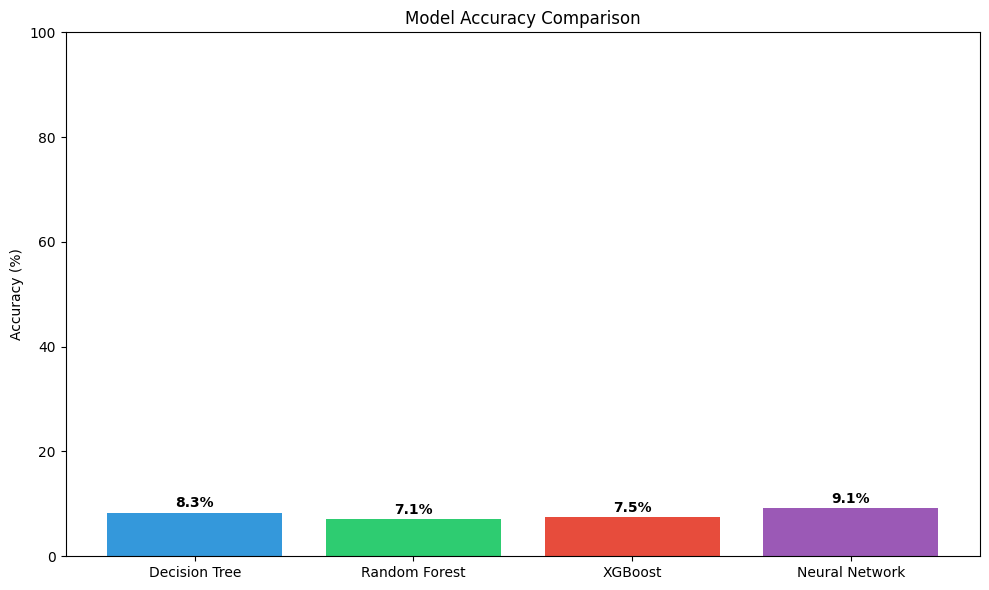

In [27]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# ===== MODEL 2: Random Forest =====
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")

# ===== MODEL 3: XGBoost =====
xgb_model = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    random_state=42, use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy:       {accuracy_xgb:.4f} ({accuracy_xgb*100:.2f}%)")

# ===== MODEL 4: Simple Neural Network (Deep Learning) =====
# (Your problem statement mentions Deep Learning / TensorFlow)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

num_classes = len(target_encoder.classes_)
num_features = X_train.shape[1]

nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(num_features,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

nn_model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

history = nn_model.fit(X_train, y_train,
                       epochs=50, batch_size=32,
                       validation_split=0.2, verbose=1)

# Evaluate Neural Network
nn_loss, nn_accuracy = nn_model.evaluate(X_test, y_test)
print(f"\nNeural Network Accuracy: {nn_accuracy:.4f} ({nn_accuracy*100:.2f}%)")

# ===== COMPARISON =====
print("\n" + "=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
results = {
    'Decision Tree': accuracy_dt,
    'Random Forest': accuracy_rf,
    'XGBoost': accuracy_xgb,
    'Neural Network': nn_accuracy
}
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:25s}: {acc:.4f} ({acc*100:.2f}%)")

# Visualize comparison
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), [v*100 for v in results.values()], color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 100)
for i, (name, acc) in enumerate(results.items()):
    plt.text(i, acc*100 + 1, f'{acc*100:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(r'd:\internship\reports\model_comparison.png')
plt.show()


In [28]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Fine-tune your best model (example: Random Forest)
# Adjust this based on which model performed best on Day 11

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Use RandomizedSearchCV (faster than GridSearchCV)
rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,           # Try 20 random combinations
    cv=5,                # 5-fold cross validation
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,           # Use all CPU cores
    verbose=1
)

rf_random.fit(X_train, y_train)

print(f"\nBest parameters: {rf_random.best_params_}")
print(f"Best CV accuracy: {rf_random.best_score_:.4f}")

# Evaluate the tuned model on test set
best_model = rf_random.best_estimator_
y_pred_tuned = best_model.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned model test accuracy: {accuracy_tuned:.4f} ({accuracy_tuned*100:.2f}%)")

# Compare: before vs after tuning
print(f"\nImprovement: {(accuracy_tuned - accuracy_rf)*100:.2f}% points")


Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 30}
Best CV accuracy: 0.0889
Tuned model test accuracy: 0.0840 (8.40%)

Improvement: 1.30% points


In [29]:
import joblib

# Save the best ML model
joblib.dump(best_model, r'd:\internship\models\best_model.pkl')
print("✅ Best model saved!")

# If Neural Network was best, save it differently:
# nn_model.save(r'd:\internship\models\nn_model.h5')

# Save final classification report
final_report = classification_report(y_test, y_pred_tuned,
                                      target_names=target_encoder.classes_,
                                      output_dict=True)
report_df = pd.DataFrame(final_report).transpose()
report_df.to_csv(r'd:\internship\reports\final_classification_report.csv')
print("✅ Classification report saved!")

# Verify everything is saved
import os
model_files = os.listdir(r'd:\internship\models')
print(f"\nSaved model files: {model_files}")

# Quick test: Load and predict
loaded_model = joblib.load(r'd:\internship\models\best_model.pkl')
test_prediction = loaded_model.predict(X_test[:1])
predicted_role = target_encoder.inverse_transform(test_prediction)
print(f"\nTest prediction: {predicted_role[0]}")

# Create a summary of the final model
print("\n" + "=" * 50)
print("FINAL MODEL SUMMARY")
print("=" * 50)
print(f"Model type: {type(best_model).__name__}")
print(f"Test accuracy: {accuracy_tuned:.4f} ({accuracy_tuned*100:.2f}%)")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of classes: {len(target_encoder.classes_)}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


✅ Best model saved!
✅ Classification report saved!

Saved model files: ['best_model.pkl', 'feature_names.pkl', 'label_encoders.pkl', 'target_encoder.pkl', 'X_test.npy', 'X_train.npy', 'y_test.npy', 'y_train.npy']

Test prediction: UX Designer

FINAL MODEL SUMMARY
Model type: RandomForestClassifier
Test accuracy: 0.0840 (8.40%)
Number of features: 19
Number of classes: 12
Training samples: 5520
Testing samples: 1381
